In [1]:
import numpy as np
def N_mean(fasta_file):
    f = open(fasta_file, 'r')
    N_dict = {}
    for line in f:
        if line[0] == '>':
            seq_ID = line[line.find('>')+1:].rstrip()
        else:
            len_seq = len(line.rstrip())
            N_number = line.count('N')
            N_mean = float(N_number) / len_seq
            raw = [len_seq, N_number, N_mean]
            N_dict[seq_ID] = raw
    f.close()
    return N_dict
def retire_amb_seqs(fasta_file, N_mean_min = 0.1):
    N_data = N_mean(fasta_file)
    f = open(fasta_file, 'r')
    out_name = fasta_file[:fasta_file.find('.fa')] + '_no_amb_seqs.fasta'
    f_out = open(out_name, 'w')
    for line in f:
        if line[0] == '>':
            seq_key = line[line.find('>')+1:].rstrip()
        elif N_data[seq_key][2] <= N_mean_min:
            new_line = '>' + seq_key + '\n'
            f_out.write(new_line)
            f_out.write(line)
        else:
            continue
    f.close()
    f_out.close()
def longest_seq(fasta_file):
    f = open(fasta_file, 'r')
    long_seq = 0
    for line in f:
        if line[0] != '>' and len(line.rstrip()) > long_seq:
            long_seq = len(line.rstrip())
    f.close()
    return long_seq
def N_positions_frequency(fasta_file):
    seqs = change_Seq_to_list(fasta_file)
    long_seq = longest_seq(fasta_file)
    N_count = []
    analized_seq = []
    N_freq = []
    for seq in seqs:
        if len(seq) < long_seq:
            for i in range(long_seq-len(seq)):
                seq.append('*')
    seqs = np.array(seqs)
    traspose_seqs = seqs.transpose()
    for line in traspose_seqs:
        N_count.append(list(line).count('N'))
        analized_seq.append((len(line) - list(line).count('*')))
        N_freq.append(float(list(line).count('N')/(len(line) - list(line).count('*'))))
    return [N_count, analized_seq, N_freq]
def change_Seq_to_list(fasta_file):
    f = open(fasta_file,'r')
    seqs = []
    for line in f:
        if line[0] != '>':
            seqs.append(list(line.rstrip()))
    return seqs

In [3]:
retire_amb_seqs('Latrodectushesperuswith_N.fasta')
retire_amb_seqs('Leucaugevenustawith_N.fasta')
retire_amb_seqs('Leucaugevenusta_2with_N.fasta')
retire_amb_seqs('Nephilaantipodianawith_N.fasta')
retire_amb_seqs('Parasteatodatepidariorumwith_N.fasta')
retire_amb_seqs('Steatodagrossawith_N.fasta')

In [4]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Latrodectushesperuswith_N.fasta',
 'Latrodectushesperuswith_N_no_amb_seqs.fasta',
 'Leucaugevenustawith_N.fasta',
 'Leucaugevenustawith_N_no_amb_seqs.fasta',
 'Leucaugevenusta_2with_N.fasta',
 'Leucaugevenusta_2with_N_no_amb_seqs.fasta',
 'Nephilaantipodianawith_N.fasta',
 'Nephilaantipodianawith_N_no_amb_seqs.fasta',
 'N_treat_consensus.ipynb',
 'Parasteatodatepidariorumwith_N.fasta',
 'Parasteatodatepidariorumwith_N_no_amb_seqs.fasta',
 'Steatodagrossawith_N.fasta',
 'Steatodagrossawith_N_no_amb_seqs.fasta']

In [5]:
L_hesperus_N_freq = N_positions_frequency('Latrodectushesperuswith_N_no_amb_seqs.fasta')
L_venusta_N_freq = N_positions_frequency('Leucaugevenustawith_N_no_amb_seqs.fasta')
L_venusta_2_N_freq = N_positions_frequency('Leucaugevenusta_2with_N_no_amb_seqs.fasta')
N_antipodiana_N_freq = N_positions_frequency('Nephilaantipodianawith_N_no_amb_seqs.fasta')
P_tepidariourum_N_freq = N_positions_frequency('Parasteatodatepidariorumwith_N_no_amb_seqs.fasta')
s_grossa_N_freq = N_positions_frequency('Steatodagrossawith_N_no_amb_seqs.fasta')

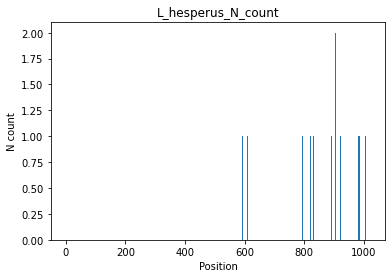

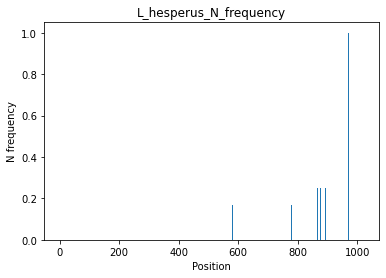

In [10]:
import matplotlib.pyplot as plt

plt.bar(list(range(len(L_hesperus_N_freq[0]))),L_hesperus_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('L_hesperus_N_count')
plt.savefig('L_hesperus_consensus_N_number.pdf')
plt.show()

plt.bar(list(range(len(L_hesperus_N_freq[0]))),L_hesperus_N_freq[2])
plt.xlabel('Position')
plt.ylabel('N frequency')
plt.title('L_hesperus_N_frequency')
plt.savefig('L_hesperus_consensus_N_frequency.pdf')
plt.show()



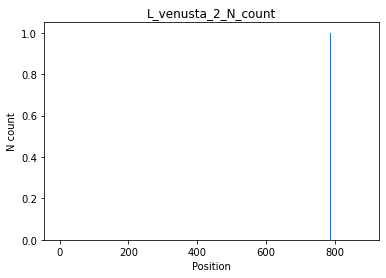

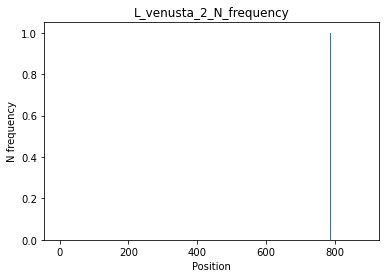

In [11]:
plt.bar(list(range(len(L_venusta_2_N_freq[0]))),L_venusta_2_N_freq[0])
plt.xlabel('Position')
plt.ylabel('N count')
plt.title('L_venusta_2_N_count')
plt.savefig('L_venusta_2_consensus_N_number.pdf')
plt.show()

plt.bar(list(range(len(L_venusta_2_N_freq[0]))),L_venusta_2_N_freq[2])
plt.xlabel('Position')
plt.ylabel('N frequency')
plt.title('L_venusta_2_N_frequency')
plt.savefig('L_venusta_2_consensus_N_frequency.pdf')
plt.show()

In [1]:
def trim_N_sequences(fasta_no_amb):
    f = open(fasta_no_amb,'r')
    out_name = fasta_no_amb[:fasta_no_amb.find('.fasta')] + '_trimed.fasta'
    f_out = open(out_name,'w')
#     N_freq = N_positions_frequency(fasta_no_amb)
#     trim_positions = trim_positions_list(N_freq[0])
    for line in f:
        if line[0] != '>':
            i = 0
            fragments = []
            found = 0
            last_cut = found
            sequence = line.rstrip()
            while found != -1:
                found = sequence.find('N',last_cut)
                if found > -1:
                    fragment = sequence[last_cut:found]
                else:
                    fragment = sequence[last_cut:]
                if len(fragment) >= 100:
                    fragments.append(fragment)
                last_cut = found + 1
#             while trim_positions[i] < len(line.strip()):
#                 fragment = line[last_cut:trim_positions[i]] 
#                 last_cut = trim_positions[i] + 1
#                 if len(fragment) >= 100:
#                     fragments.append(fragment)
#                 i += 1
#             fragment = line[last_cut:]
#             if len(fragment) >= 100:
#                 fragments.append(fragment)
            j = 0
            for frags in fragments:
                head_trim = head.rstrip() + '_frag_' + str(j)
                f_out.write(head_trim + '\n')
                f_out.write(frags+ '\n')
        else:
            head = line
    
    f.close()
    f_out.close()
    print(fasta_no_amb + ' done ')

In [2]:
trim_N_sequences('Latrodectushesperuswith_N_no_amb_seqs.fasta')
trim_N_sequences('Leucaugevenustawith_N_no_amb_seqs.fasta')
trim_N_sequences('Leucaugevenusta_2with_N_no_amb_seqs.fasta')
trim_N_sequences('Nephilaantipodianawith_N_no_amb_seqs.fasta')
trim_N_sequences('Parasteatodatepidariorumwith_N_no_amb_seqs.fasta')
trim_N_sequences('Steatodagrossawith_N_no_amb_seqs.fasta')

Latrodectushesperuswith_N_no_amb_seqs.fasta done 
Leucaugevenustawith_N_no_amb_seqs.fasta done 
Leucaugevenusta_2with_N_no_amb_seqs.fasta done 
Nephilaantipodianawith_N_no_amb_seqs.fasta done 
Parasteatodatepidariorumwith_N_no_amb_seqs.fasta done 
Steatodagrossawith_N_no_amb_seqs.fasta done 
